# ANÁLIISIS PARA UNA PREDICCIÓN DEL MODELO

Se presentan los códigos desarrollados de manera organizada, comprensible y concisa, importando las funciones desarrolladas en los Notebooks anteriores, las que fueron implementadas como paquetes en archivos `xai_utils/*.py`.




In [1]:
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', message='Unable to find acceptable character detection dependency')

from keras.models import load_model
import pickle

In [2]:
from xai_utils import analyze_with_confetti
from xai_utils import (plot_best_counterfactual, plot_counterfactuals_by_diff,
                        plot_counterfactuals_by_ts, plot_counterfactual_channels,
                        plot_cf_summary)

In [3]:
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
#y_test = load_pickle(data_path+'ytest_new.pickle')
X_test = load_pickle(data_path+'xtest_new.pickle')
# y_train = load_pickle(data_path+'ytrain_new.pickle')
X_train = load_pickle(data_path+'xtrain_new.pickle')
# y_val = load_pickle(data_path+'yval_new.pickle')
# X_val = load_pickle(data_path+'xval_new.pickle')

In [4]:
model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras') #Cargar modelo
m=1
instance = X_test[m:m+1] #Seleccionar la serie de tiempo a evaluar
model.predict(instance) #Predecir para ver el resultado


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


array([[0.99999976]], dtype=float32)

In [8]:
#Prueba rapida
resultados_cf = analyze_with_confetti(
    model_path_wrapped='MODELS\\transfer_learned_tsunami_classifier_wrapped.keras',
    model_path_original='MODELS\\transfer_learned_tsunami_classifier.keras',
    instance=instance,
    training_weights_path=None, #'MODELS\\training_weights_resized.npy',
    X_train=X_train,
    n_partitions=5,           # menos segmentos = más rápido
    alpha=0.5,           # restricción de sparsity
    theta=0.51,           # umbral para cambio de clase
    optimize_sparsity=True,  # desactivar para prueba rápida
    population_size=300,       # reducido drásticamente
    maximum_number_of_generations=500,  # reducido drásticamente
    feature_names=['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6'],
    save_path='RESULTADOS_CONFETTI\\'
)

Cargando modelo original y calculando pesos CAM...
  Inicio: 12:52:13
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.3, optimize_sparsity=True, population_size=300
¡Generación completada! Fin: 13:38:18
Contrafactuales generados: 55
Resultados guardados en: RESULTADOS_CONFETTI\_resultados_cf.pkl


In [6]:
# Se guardan los resultados

with open('RESULTADOS_CONFETTI\\resultados_confetti.pkl', 'wb') as f:
    pickle.dump(resultados_cf, f)

Figura guardada: RESULTADOS_CONFETTI\_mejor_cf.png


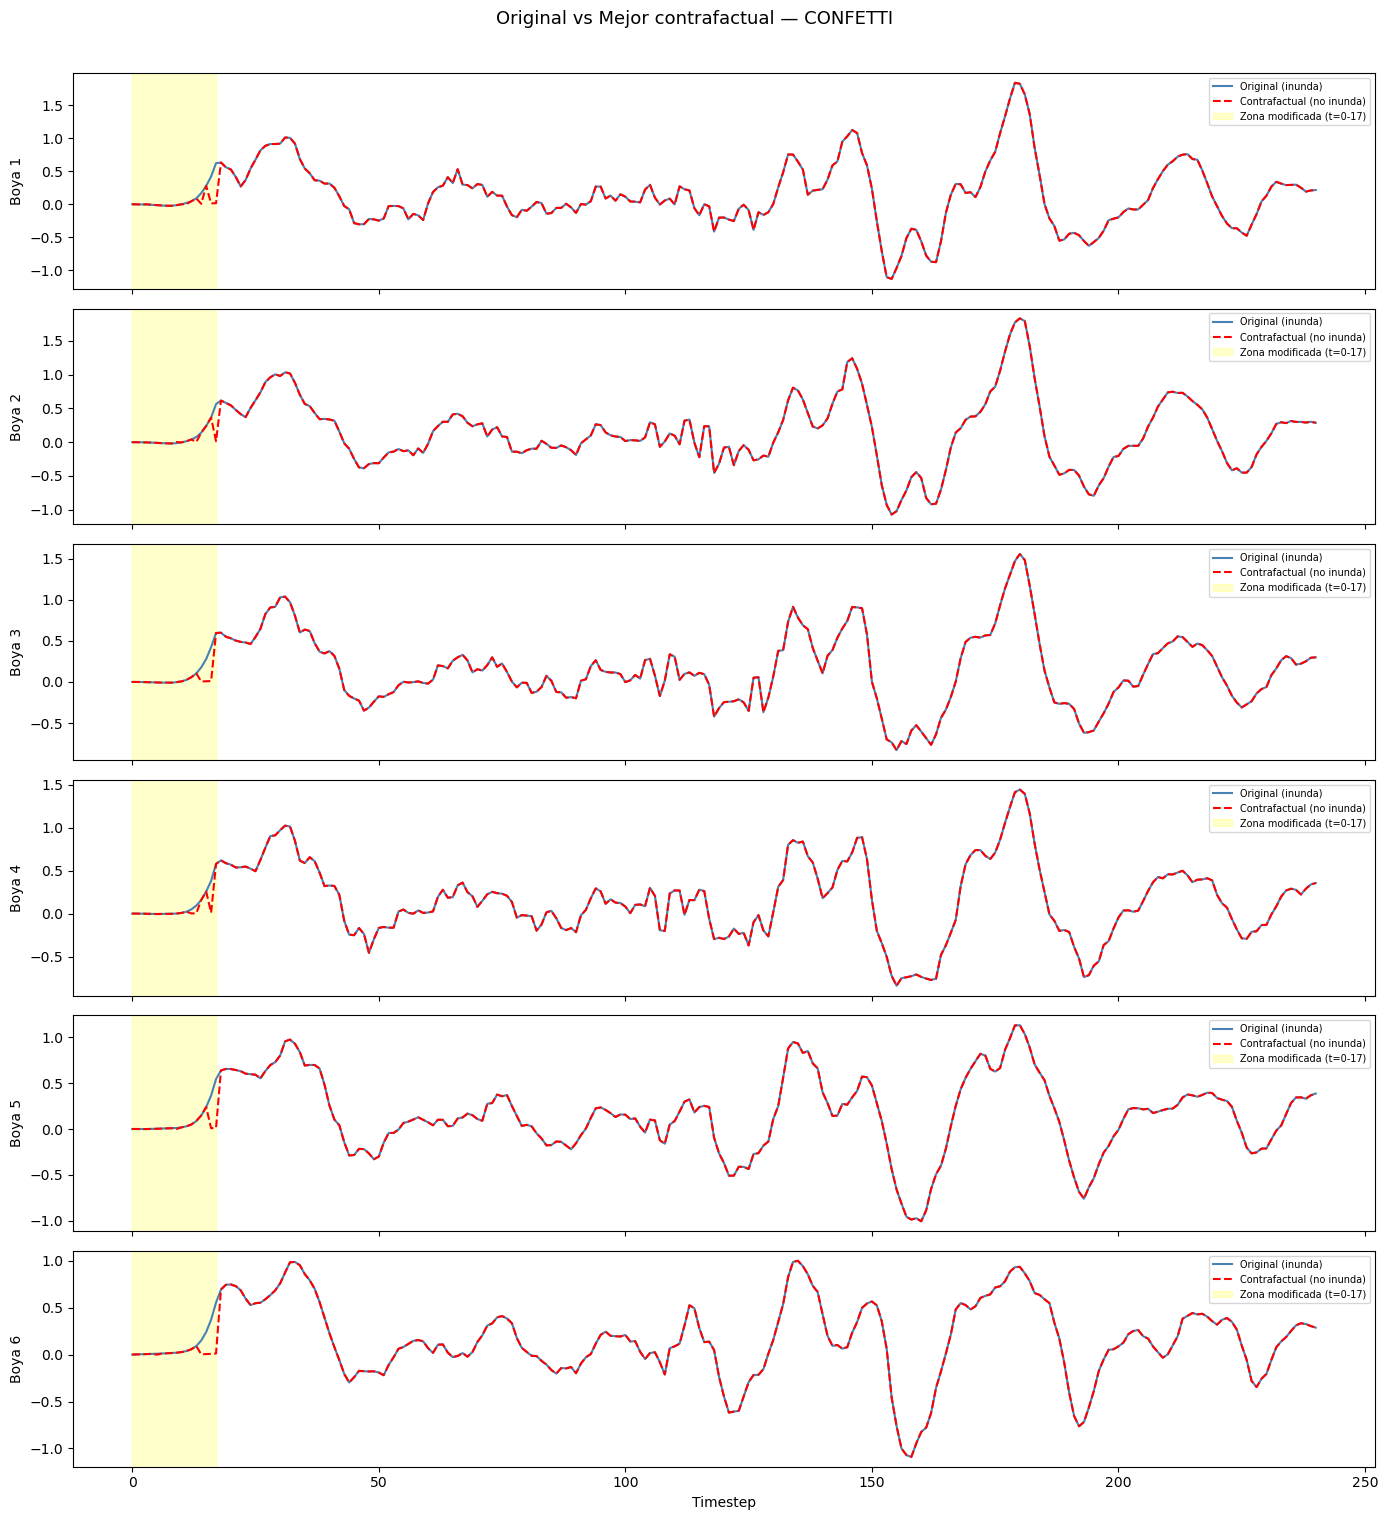

Figura guardada: RESULTADOS_CONFETTI\_cf_por_diff.png


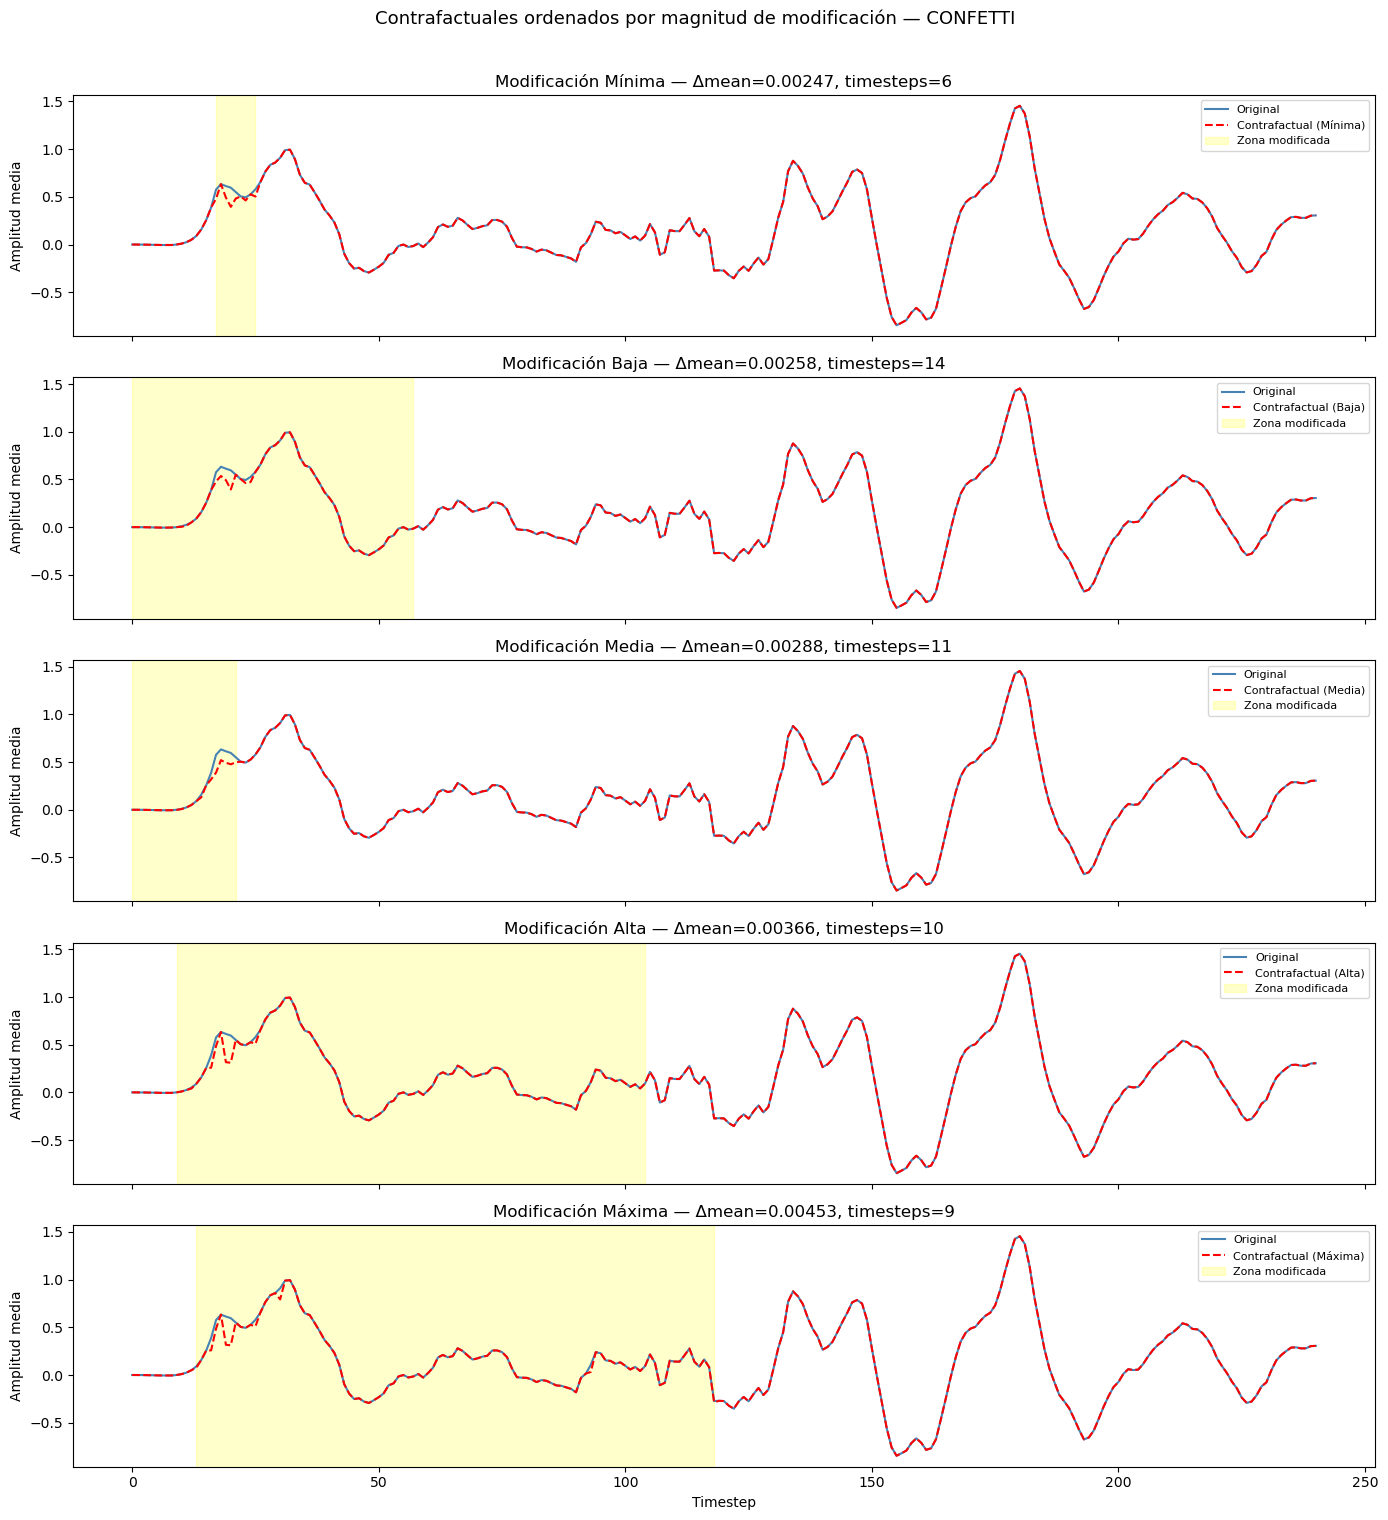

Figura guardada: RESULTADOS_CONFETTI\_cf_por_ts.png


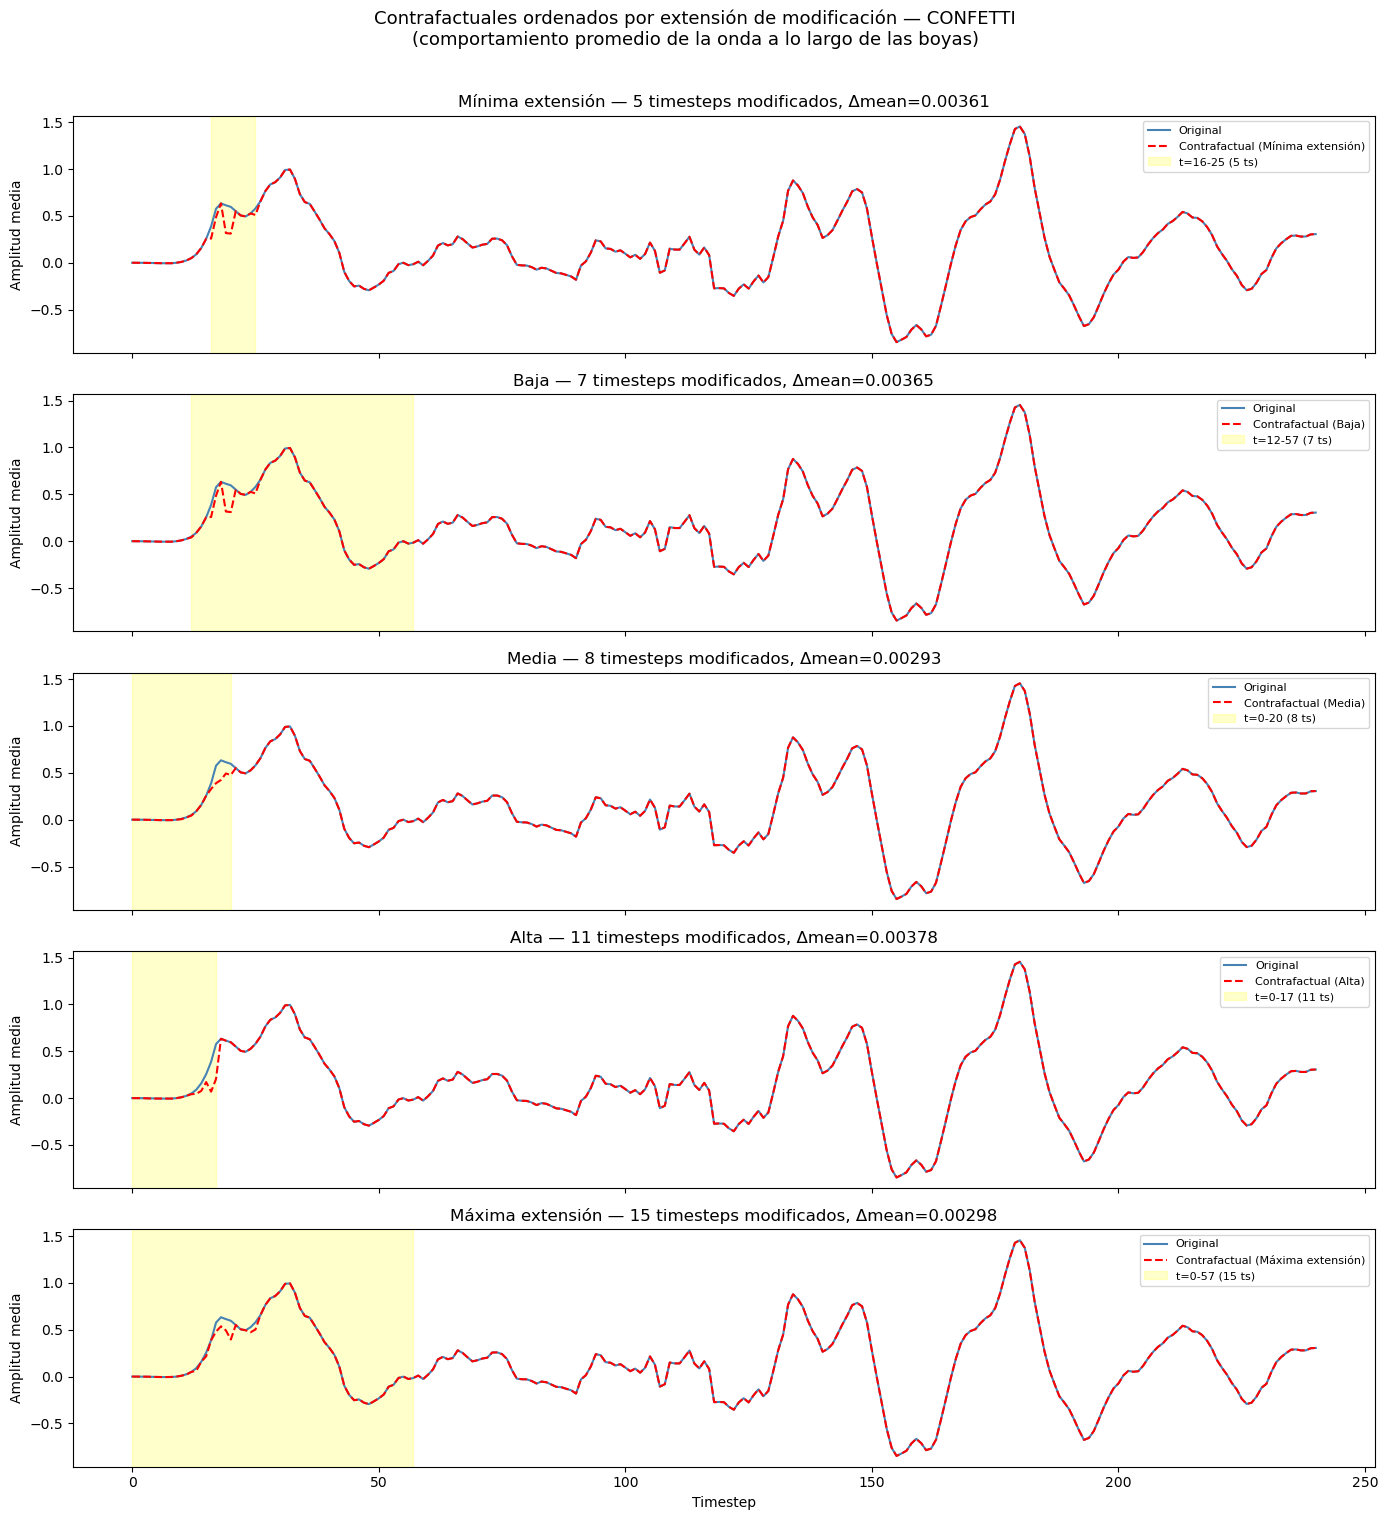

Figura guardada: RESULTADOS_CONFETTI\_cf_canales_0.png


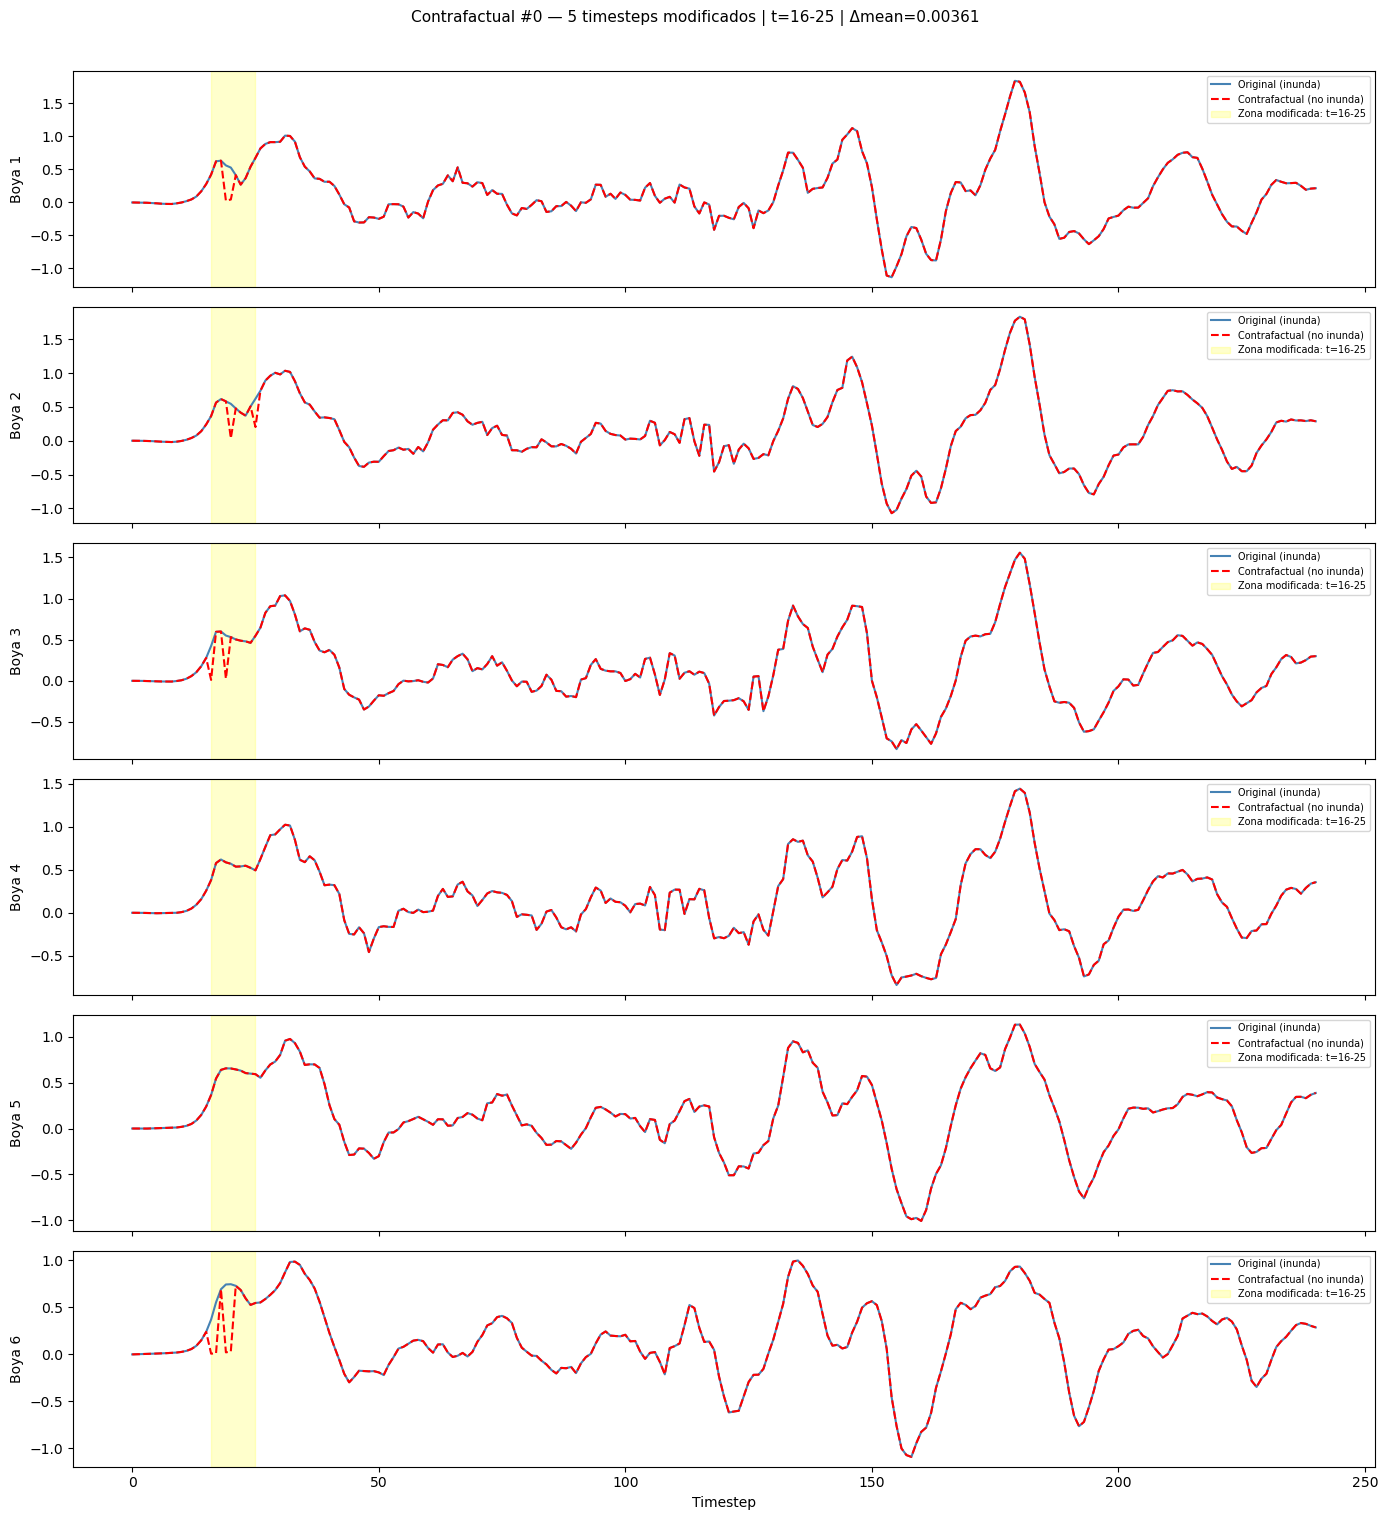

Figura guardada: RESULTADOS_CONFETTI\_resumen_cf.png


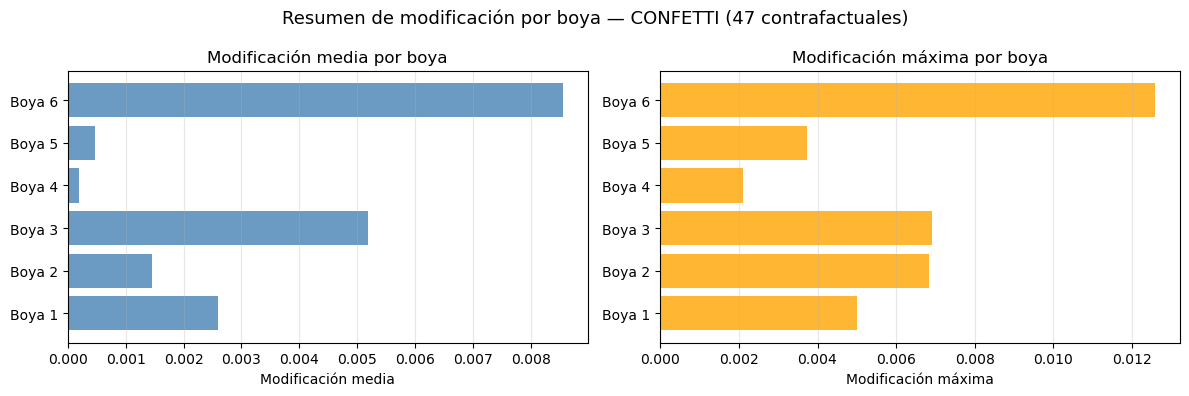

In [7]:
# Gráficos
plot_best_counterfactual(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactuals_by_diff(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactuals_by_ts(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactual_channels(resultados_cf, cf_index=0, cf_sorted_key='ts', save_path='RESULTADOS_CONFETTI\\')
plot_cf_summary(resultados_cf, save_path='RESULTADOS_CONFETTI\\')